In [2]:
# setup — если minigrid/transformers ставятся впервые, сделай Run > Restart
!pip install -q -U minigrid "transformers>=4.49" accelerate qwen-vl-utils

## Qwen кросс-матрица на новой среде (size=10, стены, углы)

Проверяем, различает ли скорер три задачи **после** увеличения поля (ключ в
кадре 64px стал мельче/размытее). Гоняем матрицу на **двух** разрешениях:
- **256px** — чистый рендер, потолок качества;
- **64px** — то, что реально видит планировщик (выход декодера такого же размера).

Если диагональ выживает на 64px — маркер рабочий на входе планировщика.
Особое внимание на **key-столбец**: у него и раньше был тонкий запас.

In [3]:
import os, sys, glob
import numpy as np
import torch
from PIL import Image

# найти файлы проекта где бы они ни лежали в датасете и импортировать напрямую
hit = glob.glob("/kaggle/input/datasets/kirillwerd/world-model-new", recursive=True)
assert hit, "env_tasks.py не найден в /kaggle/input — приаттачь датасет с файлами проекта"
SRC = "/kaggle/input/datasets/kirillwerd/world-model-new"
sys.path.insert(0, SRC)
print("src dir:", SRC)

from env_tasks import MultiObjEnv
from Kaggle_Scorer import KaggleScorer

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", DEVICE)

src dir: /kaggle/input/datasets/kirillwerd/world-model-new
device: cuda


In [4]:
# 3B — рабочий выбор: 2B хеджирует, 7B не влезает в T4.
scorer = KaggleScorer(model="Qwen/Qwen2.5-VL-3B-Instruct")
print("model:", scorer.model_name, "| device:", scorer.device, "| dtype:", scorer.dtype)

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/824 [00:00<?, ?it/s]

model: Qwen/Qwen2.5-VL-3B-Instruct | device: cuda | dtype: torch.bfloat16


### Кадры «рядом + остриём» и кросс-матрица

`approach_pose` ставит агента в свободную клетку рядом с объектом и разворачивает
остриём на него (объект остаётся виден). `cross_matrix` скорит каждый кадр против
каждого промпта; **row-softmax** нормирует кадр против конкурирующих целей (честный
debias). Рабочий скорер = доминирующая диагональ (3/3).

target -> agent pose:
   key: obj@(1, 5)  agent@(1, 4) dir=1  (рядом, остриём)
  door: obj@(8, 1)  agent@(7, 1) dir=0  (рядом, остриём)
  goal: obj@(8, 8)  agent@(8, 8) dir=0  (НА клетке)

=== 256px (потолок) ===
raw P(Yes)   rows=frame  cols=prompt
           key    door    goal
   key   0.593   0.500   0.593
  door   0.349   0.881   0.531
  goal   0.531   0.469   0.881
row-softmax  (кадр -> какой промпт выигрывает; диагональ должна доминировать)
   key   0.343   0.313   0.343   -> goal
  door   0.256   0.436   0.308   -> door
  goal   0.298   0.280   0.422   -> goal
diagonal hits: 2/3

=== 64px (вход планировщика) ===
raw P(Yes)   rows=frame  cols=prompt
           key    door    goal
   key   0.777   0.593   0.706
  door   0.500   0.755   0.438
  goal   0.622   0.562   0.915
row-softmax  (кадр -> какой промпт выигрывает; диагональ должна доминировать)
   key   0.362   0.301   0.337   -> key
  door   0.310   0.399   0.291   -> door
  goal   0.305   0.287   0.408   -> goal
diagonal hi

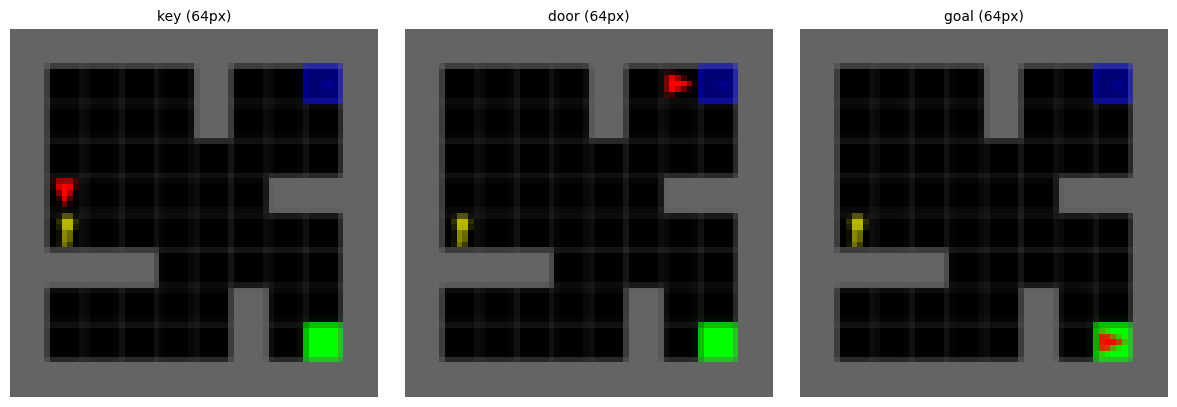

In [8]:
import matplotlib.pyplot as plt
from minigrid.core.world_object import Key, Door, Goal

DIR_VEC = [(1, 0), (0, 1), (-1, 0), (0, -1)]      # 0=right 1=down 2=left 3=up

PROMPTS = {
    "key":  "the red agent is right next to the yellow key, pointing at it",
    "door": "the red agent is right next to the blue door, pointing at it",
    "goal": "the red agent is standing on the green goal square",
}

# goal standable (can_overlap) => агент СТОИТ НА нём: это success-состояние at_goal
# и совпадает с промптом "standing on". key/door — встать нельзя, успех = adjacent,
# поэтому им остаётся approach_pose (рядом + остриём).
POSE_MODE = {"key": "adjacent", "door": "adjacent", "goal": "on"}


def find_obj(env, cls):
    for x in range(env.width):
        for y in range(env.height):
            if isinstance(env.grid.get(x, y), cls):
                return (x, y)
    return None


def approach_pose(env, target):
    """Свободная соседняя клетка + направление остриём на target (объект виден)."""
    tx, ty = target
    for d, (dx, dy) in enumerate(DIR_VEC):
        nx, ny = tx - dx, ty - dy
        if 0 <= nx < env.width and 0 <= ny < env.height and env.grid.get(nx, ny) is None:
            return (nx, ny), d
    return target, 0


def on_pose(env, target, d=0):
    """Агент СТОИТ НА клетке target (standable-цели, напр. goal). Это ровно
    success-состояние at_goal; агент частично заслоняет квадрат — прямая
    проверка, вытягивает ли Qwen окклюзию (ради этого и брали yes/no вместо CLIP)."""
    return target, d


def make_pose(env, task, target):
    return on_pose(env, target) if POSE_MODE[task] == "on" else approach_pose(env, target)


def render_pose(env, pos, d, seed=0):
    env.reset(seed=seed)                              # random_start не важен: перезаписываем позу
    env.agent_pos = np.array(pos)
    env.agent_dir = d
    return env.render()


def to64(rgb):
    return np.asarray(Image.fromarray(rgb.astype(np.uint8)).resize((64, 64), Image.BILINEAR))


# ---- позы: goal — НА клетке; key/door — рядом + остриём ----
env = MultiObjEnv(render_mode="rgb_array", highlight=False)     # size=10 по умолчанию
env.reset(seed=0)
targets = {"key": find_obj(env, Key), "door": find_obj(env, Door), "goal": tuple(env.goal_pos)}

names, poses = [], {}
for name, t in targets.items():
    poses[name] = make_pose(env, name, t)
    names.append(name)

print("target -> agent pose:")
for n in names:
    where = "НА клетке" if POSE_MODE[n] == "on" else "рядом, остриём"
    print(f"  {n:>4}: obj@{targets[n]}  agent@{poses[n][0]} dir={poses[n][1]}  ({where})")

frames256 = [render_pose(env, poses[n][0], poses[n][1]) for n in names]
frames64  = [to64(f) for f in frames256]


def cross_matrix(frames, tag):
    pk = list(PROMPTS)
    M = torch.zeros(len(names), len(pk))
    for j, k in enumerate(pk):
        scorer.set_goal(PROMPTS[k])
        M[:, j] = scorer.score_rgb(frames)
    print(f"\n=== {tag} ===")
    print("raw P(Yes)   rows=frame  cols=prompt")
    print("        " + "  ".join(f"{k:>6}" for k in pk))
    for i, n in enumerate(names):
        print(f"{n:>6}  " + "  ".join(f"{M[i, j]:6.3f}" for j in range(len(pk))))
    S = M.softmax(dim=1); hits = 0
    print("row-softmax  (кадр -> какой промпт выигрывает; диагональ должна доминировать)")
    for i, n in enumerate(names):
        win = pk[int(S[i].argmax())]; hits += (win == n)
        print(f"{n:>6}  " + "  ".join(f"{S[i, j]:6.3f}" for j in range(len(pk))) + f"   -> {win}")
    print(f"diagonal hits: {hits}/{len(names)}")
    return M


M256 = cross_matrix(frames256, "256px (потолок)")
M64  = cross_matrix(frames64,  "64px (вход планировщика)")

# визуал: то, что видит планировщик (64px)
fig, ax = plt.subplots(1, len(names), figsize=(4 * len(names), 4))
for a, n, img in zip(np.atleast_1d(ax), names, frames64):
    a.imshow(img); a.set_title(f"{n} (64px)", fontsize=10); a.axis("off")
plt.tight_layout(); plt.savefig("qwen_cross_64.png", dpi=110); plt.show()